In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re
import string

In [22]:
df = pd.read_csv("../data/fake_job_postings.csv")   # Adjust path if needed
df.head()

,title,location,description,requirements,telecommuting,has_company_logo,has_questions,fraudulent
0,Architect (Middleware - MQ) - Kuwait,"KW, KU,","On behalf of our client, a well known multinat...",-Working technical knowledge of IT systems and...,0,1,0,0
1,Interviewing Now for Sales Rep Positions -- wi...,"US, TX, Corpus Christi","We are Argenta Field Solutions, a rapidly expa...",#NAME?,0,1,0,0
2,Process Controls Staff Engineer - Foxboro I/A ...,"US, TX, USA Southwest",Experienced Process Controls Staff Engineer is...,At least 10 years of degreed professional expe...,0,0,0,0
3,Experienced Telemarketer Wanted - Digital Solu...,"AU, NSW,",If you have a passion for people and love to s...,"Responsibilities - Prospecting, following up a...",0,1,0,0
4,Senior Network Engineer,"GB, ENG, London",As the successful Senior Network Engineer you ...,Essential skills:•Juniper switching/routing/se...,0,1,0,0


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8940 entries, 0 to 8939
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   title             8940 non-null   object
 1   location          8783 non-null   object
 2   description       8939 non-null   object
 3   requirements      7614 non-null   object
 4   telecommuting     8940 non-null   int64 
 5   has_company_logo  8940 non-null   int64 
 6   has_questions     8940 non-null   int64 
 7   fraudulent        8940 non-null   int64 
dtypes: int64(4), object(4)
memory usage: 558.9+ KB


In [24]:
df.shape

(8940, 8)

In [25]:
df.describe(include="all")

,title,location,description,requirements,telecommuting,has_company_logo,has_questions,fraudulent
count,8940,8783,8939,7614,8940.000000,8940.000000,8940.000000,8940.000000
unique,6132,2131,7767,6327,NaN,NaN,NaN,NaN
top,English Teacher Abroad,"GB, LND, London","Play with kids, get paid for it Love travel? J...",University degree required. TEFL / TESOL / CEL...,NaN,NaN,NaN,NaN
freq,152,367,187,200,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,0.043736,0.794407,0.487248,0.051007
std,NaN,NaN,NaN,NaN,0.204519,0.404157,0.499865,0.220024
min,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,NaN,NaN,0.000000,1.000000,0.000000,0.000000
50%,NaN,NaN,NaN,NaN,0.000000,1.000000,0.000000,0.000000
75%,NaN,NaN,NaN,NaN,0.000000,1.000000,1.000000,0.000000


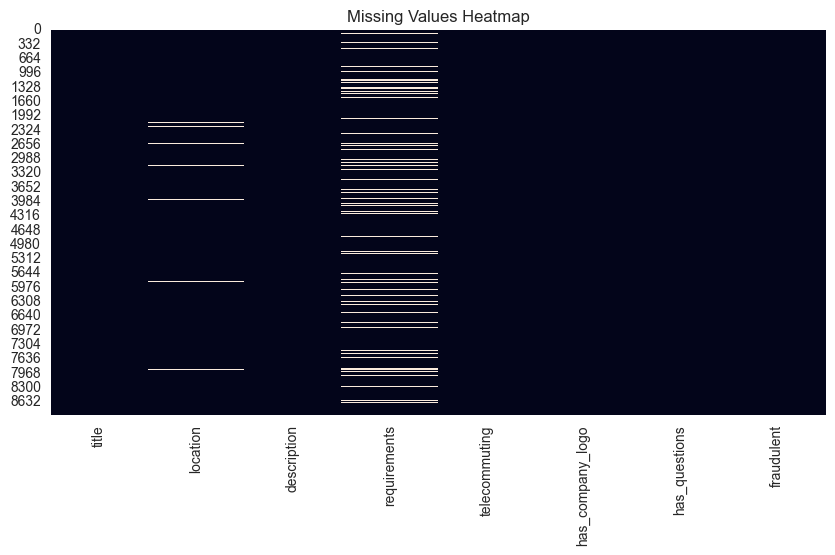

In [26]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

In [27]:
df.isnull().sum().sort_values(ascending=False)

requirements        1326
location             157
description            1
title                  0
telecommuting          0
has_company_logo       0
has_questions          0
fraudulent             0
dtype: int64

In [28]:
cat_cols = ['title', 'location', 'description', 'requirements']

for col in cat_cols:
    df[col] = df[col].fillna("Unknown")

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8940 entries, 0 to 8939
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   title             8940 non-null   object
 1   location          8940 non-null   object
 2   description       8940 non-null   object
 3   requirements      8940 non-null   object
 4   telecommuting     8940 non-null   int64 
 5   has_company_logo  8940 non-null   int64 
 6   has_questions     8940 non-null   int64 
 7   fraudulent        8940 non-null   int64 
dtypes: int64(4), object(4)
memory usage: 558.9+ KB


In [30]:
df.isnull().sum()

title               0
location            0
description         0
requirements        0
telecommuting       0
has_company_logo    0
has_questions       0
fraudulent          0
dtype: int64

In [31]:
df.drop_duplicates(inplace=True)
df.shape

(8835, 8)

In [32]:
df['fraudulent'].value_counts()

fraudulent
0    8389
1     446
Name: count, dtype: int64

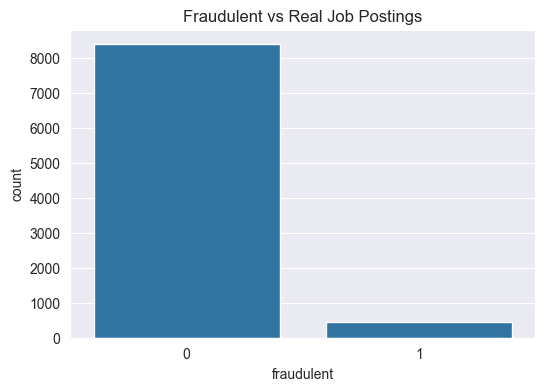

In [33]:
plt.figure(figsize=(6,4))
sns.countplot(data = df, x = 'fraudulent')
plt.title("Fraudulent vs Real Job Postings")
plt.show()

In [34]:
#Creating a clean text column
df['text'] = (
    df['title'].fillna('') + " " +
    df['description'].fillna('') + " " +
    df['requirements'].fillna('')
)

In [35]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)               # remove URLs
    text = re.sub(r"<.*?>", "", text)                 # remove HTML tags
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\d+", "", text)                   # remove numbers
    text = re.sub(r"\s+", " ", text).strip()          # remove extra spaces
    return text

df['clean_text'] = df['text'].apply(clean_text)
df['clean_text'].head()

0    architect middleware mq kuwait on behalf of ou...
1    interviewing now for sales rep positions with ...
2    process controls staff engineer foxboro ia tri...
3    experienced telemarketer wanted digital soluti...
4    senior network engineer as the successful seni...
Name: clean_text, dtype: object

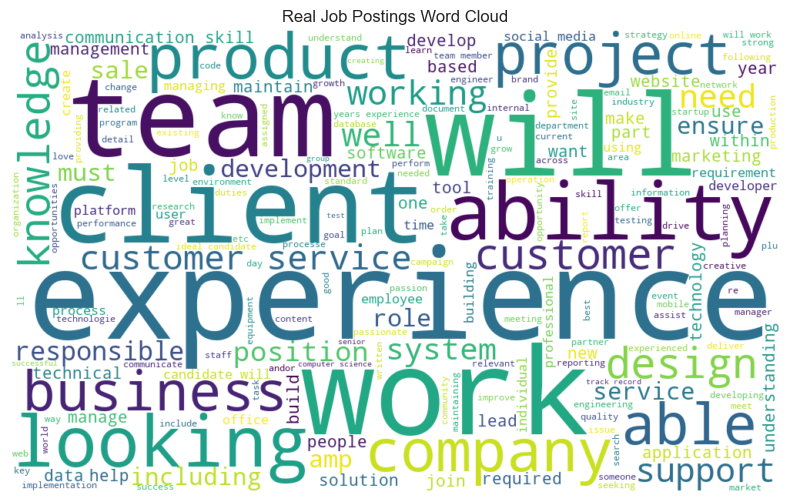

In [36]:
#WORD CLOUD FOR REAL JOBS
real_text = " ".join(df[df['fraudulent'] == 0]['clean_text'].tolist())

wordcloud = WordCloud(width=1000, height=600, background_color="white").generate(real_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Real Job Postings Word Cloud")
plt.show()

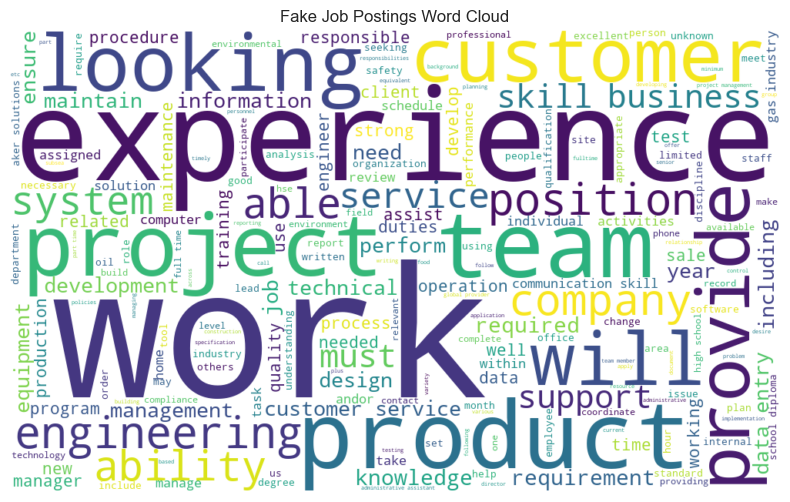

In [37]:
#WORD CLOUD FOR FAKE JOBS
fake_text = " ".join(df[df['fraudulent'] == 1]['clean_text'].tolist())

wordcloud = WordCloud(width=1000, height=600, background_color="white").generate(fake_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Fake Job Postings Word Cloud")
plt.show()

In [38]:
from collections import Counter

def top_words(text_list, n=20):
    words = " ".join(text_list).split()
    counter = Counter(words)
    return counter.most_common(n)

print("Top Real Job Words:")
top_words(df[df['fraudulent']==0]['clean_text'])

print("\nTop Fake Job Words:")
top_words(df[df['fraudulent']==1]['clean_text'])

Top Real Job Words:

Top Fake Job Words:


[('and', 5672),
 ('to', 3044),
 ('the', 2496),
 ('of', 2004),
 ('in', 1702),
 ('a', 1642),
 ('with', 1340),
 ('for', 1302),
 ('work', 760),
 ('is', 719),
 ('are', 665),
 ('experience', 610),
 ('or', 609),
 ('you', 556),
 ('on', 543),
 ('be', 538),
 ('as', 532),
 ('skills', 463),
 ('we', 463),
 ('amp', 406)]

In [39]:
df.to_csv("../data/fake_jobs_cleaned.csv", index=False)
print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
